<a href="https://colab.research.google.com/github/juliafoliveira-tech/Bioestat-stica/blob/main/Tarefa11_variaveis_aleatorias_biologia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Julia Feitosa NºUSP: 16228410
* Raissa Pereira Lima da Silva NºUSP: 14605077  
* Stéfani Machado NºUSP: 15291452

In [4]:
import pandas as pd

df = pd.read_excel('Tarefa 11.xlsx', header=None)


Uma variável aleatória (VA) é um número que representa um resultado de uma experiência ou circunstância aleatória em um espaço amostral (espaço de todos os resultados possíveis de um experimento aleatório). Uma variável aleatória pode ser discreta ou contínua.

Com base no conjunto de dados do arquivo fornecido, os dados representam uma amostragem biológica sobre a "Disposição das ordens e famílias de insetos identificados capturados nos dois tipos de armadilhas utilizadas".

Em estatística e probabilidade, variáveis aleatórias associam valores numéricos aos resultados de um experimento aleatório (neste caso, a captura e identificação de espécimes nas armadilhas).

In [9]:
# Leia a planilha 'Tarefa 11.xlsx'.

# Identifique o cabeçalho correto e renomeie as colunas para: Ordem, Familia, Abundancia_N e Frequencia_Relativa_Pct.

# Separe o registro de resumo/total dos dados das famílias.

In [6]:
# O 'Número de Indivíduos' está na coluna de índice 2 (terceira coluna).
# Os dados de interesse para a variável aleatória estão nas linhas de índice 2 a 11 (inclusive).
# A linha 1 é o cabeçalho, e a linha 12 é o 'Total', que não devem ser incluídos.

# Seleciona o slice relevante do DataFrame (linhas 2 a 11, coluna 2)
# e converte para numérico, tratando erros.
rv_numero_individuos = pd.to_numeric(df.iloc[2:12, 2], errors='coerce')

# Remove quaisquer valores NaN que possam ter resultado da conversão (caso haja dados não numéricos inesperados)
rv_numero_individuos = rv_numero_individuos.dropna()

# Converte os números para tipo inteiro, pois representam contagens de indivíduos.
rv_numero_individuos = rv_numero_individuos.astype(int)

# Define um nome descritivo para a Série.
rv_numero_individuos.name = 'Número de Indivíduos por Família'

display(rv_numero_individuos)

,Número de Indivíduos por Família
2,295
3,7
4,1
5,1
6,137
7,9
8,1
9,1
10,1
11,2


Aqui, a variável aleatória discreta pode ser definida como o **'Número de Indivíduos por Família'**. Cada valor nesta série representa a contagem de indivíduos para uma família de insetos específica, observado em nosso experimento de coleta de dados.

Podemos analisar algumas estatísticas descritivas para essa variável aleatória:

Média do Número de Indivíduos: 45.50
Mediana do Número de Indivíduos: 1.50
Moda do Número de Indivíduos: [1]
Soma Total de Indivíduos: 455


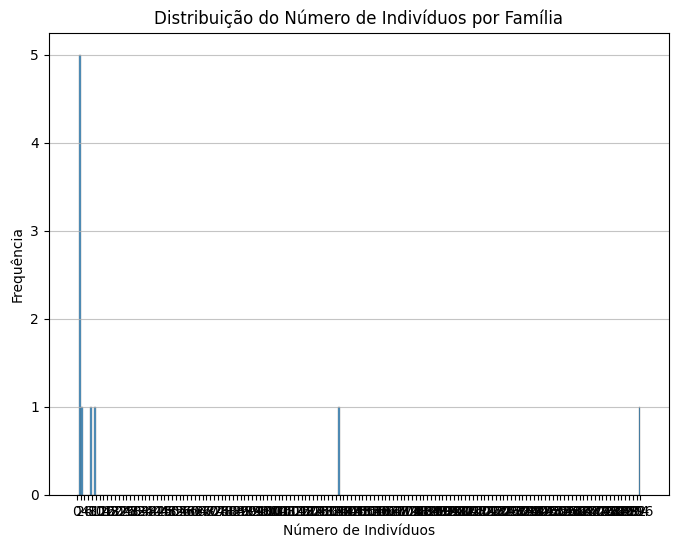

In [7]:
# Calcular estatísticas descritivas
mean_val = rv_numero_individuos.mean()
median_val = rv_numero_individuos.median()
mode_val = rv_numero_individuos.mode().tolist() # Retorna uma lista, pode ter múltiplos modos
sum_val = rv_numero_individuos.sum()

print(f"Média do Número de Indivíduos: {mean_val:.2f}")
print(f"Mediana do Número de Indivíduos: {median_val:.2f}")
print(f"Moda do Número de Indivíduos: {mode_val}")
print(f"Soma Total de Indivíduos: {sum_val}")

# Visualização da distribuição (opcional, mas útil para entender a VA)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(rv_numero_individuos, bins=range(0, rv_numero_individuos.max() + 2), kde=False)
plt.title('Distribuição do Número de Indivíduos por Família')
plt.xlabel('Número de Indivíduos')
plt.ylabel('Frequência')
plt.xticks(range(0, rv_numero_individuos.max() + 2, 2))
plt.grid(axis='y', alpha=0.75)
plt.show()

Exemplos de Variáveis Aleatórias Discretas

Variáveis discretas assumem valores numéricos finitos ou enumeráveis (geralmente números inteiros resultantes de contagens).

Abundância por família de insetos (N)
Valores observados na tabela: 295 (Scarabaeidae), 137 (Formicidae), 9 (Vespidae), etc.

Contagem de indivíduos capturados pertencentes a uma determinada família. O resultado indica apenas em números inteiros não negativos.

Número de famílias identificadas dentro de uma determinada ordem

Valores observados na tabela: 4 famílias para Coleoptera, 3 para Hymenoptera, 1 para Odonata, 1 para Diptera e 2 para Lepidoptera.

Quantidade exata de categorias taxonômicas de nível "Família" observadas dentro de cada Ordem, assumindo apenas valores inteiros finitos.

Número total de ordens distintas amostradas

Valores observados na tabela: $5$ ordens (Coleoptera, Hymenoptera, Odonata, Diptera, Lepidoptera).

É o resultado de uma contagem simples de categorias presentes na amostragem, não admitindo valores fracionários.

Exemplos de Variáveis Aleatórias Contínuas

Variáveis contínuas resultam de medições e podem assumir qualquer valor real dentro de um intervalo (incluindo números decimais/fracionários).

Frequência Relativa da amostragem por família

Valores observados na tabela: 64,69%, 30,04, 1,97%, 0,21, etc.

A frequência percentual relativa representa uma grandeza escalar contínua que varia dentro do intervalo 0% a 100%, podendo assumir infinitos valores decimais dependendo do tamanho da amostra.

Proporção da frequência relativa acumulada por ordem taxonômica

Valores observados na tabela:
Exemplo da ordem Coleoptera totalizando 66,64%; 64,69% ; 1,53%; 0,21%; 0,21%.

Representa uma medição percentual acumulada contínua no intervalo contínuo entre 0% e 100%.

In [15]:
import pandas as pd

# Carrega a planilha Excel, definindo a segunda linha (índice 1) como cabeçalho.
df_raw = pd.read_excel('Tarefa 11.xlsx', header=1)

# Identifica e separa a linha de 'Total'.
# A linha de total contém a string 'Total' na coluna 'ORDENS'.
df_total_row = df_raw[df_raw['ORDENS'].astype(str).str.contains('Total', case=False, na=False)].copy()
df_data = df_raw[~df_raw['ORDENS'].astype(str).str.contains('Total', case=False, na=False)].copy()

# Renomeia as colunas para facilitar a manipulação.
new_column_names = {
    'ORDENS': 'Ordem',
    'FAMÍLIAS': 'Familia',
    'ABUNDÂNCIA (N)': 'Abundancia_N', # Corrigido o nome da coluna aqui
    'FREQUÊNCIA RELATIVA (%)': 'Frequencia_Relativa_Pct' # Corrigido o nome da coluna aqui
}
df_data = df_data.rename(columns=new_column_names)

# Converte 'Abundancia_N' para tipo inteiro. Valores inválidos serão tratados como 0.
df_data['Abundancia_N'] = pd.to_numeric(df_data['Abundancia_N'], errors='coerce').fillna(0).astype(int)

# Converte 'Frequencia_Relativa_Pct' para tipo float.
# Substitui vírgulas por pontos para garantir a conversão correta de números decimais.
df_data['Frequencia_Relativa_Pct'] = df_data['Frequencia_Relativa_Pct'].astype(str).str.replace(',', '.', regex=False)
df_data['Frequencia_Relativa_Pct'] = pd.to_numeric(df_data['Frequencia_Relativa_Pct'], errors='coerce').fillna(0)

print("Dados limpos (primeiras 5 linhas):")
display(df_data.head())

print("\nRegistro de resumo/total:")
display(df_total_row)

Dados limpos (primeiras 5 linhas):


,Ordem,Familia,Abundancia_N,Frequencia_Relativa_Pct
0,COLEOPTERA,Scarabaeidae,295,64.69
1,COLEOPTERA,Elateridae,7,1.53
2,COLEOPTERA,Cerambycidae,1,0.21
3,COLEOPTERA,Curculionidae,1,0.21
4,HYMENOPTERA,Formicidae,137,30.04



Registro de resumo/total:


,ORDENS,FAMÍLIAS,ABUNDÂNCIA (N),FREQUÊNCIA RELATIVA (%)
11,Total,11,456,100.0


### Classificação Bioestatística das Variáveis

Com base nos dados carregados e limpos, podemos classificar as variáveis segundo a teoria estatística, o que é fundamental para a escolha das análises e visualizações adequadas.

| Variável                  | Tipo Estatístico         | Descrição                                         |
| :------------------------ | :----------------------- | :------------------------------------------------ |
| `Abundancia_N`            | Quantitativa Discreta    | Contagem do número de indivíduos.                   |
| `Frequencia_Relativa_Pct` | Quantitativa Contínua    | Proporção/Percentual da frequência em escala real. |
| `Ordem`                   | Qualitativa Nominal      | Categoria taxonômica (sem ordem inerente).       |
| `Familia`                 | Qualitativa Nominal      | Categoria taxonômica (sem ordem inerente).       |

### Visualização Gráfica para Apresentação

Serão criados dois gráficos lado a lado para visualizar a abundância por família e a distribuição percentual por ordem taxonômica, utilizando uma paleta de cores agradável e rótulos claros em português.

/tmp/ipykernel_1611/2469244572.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Abundancia_N', y='Familia', data=df_familia_sorted, palette='viridis')


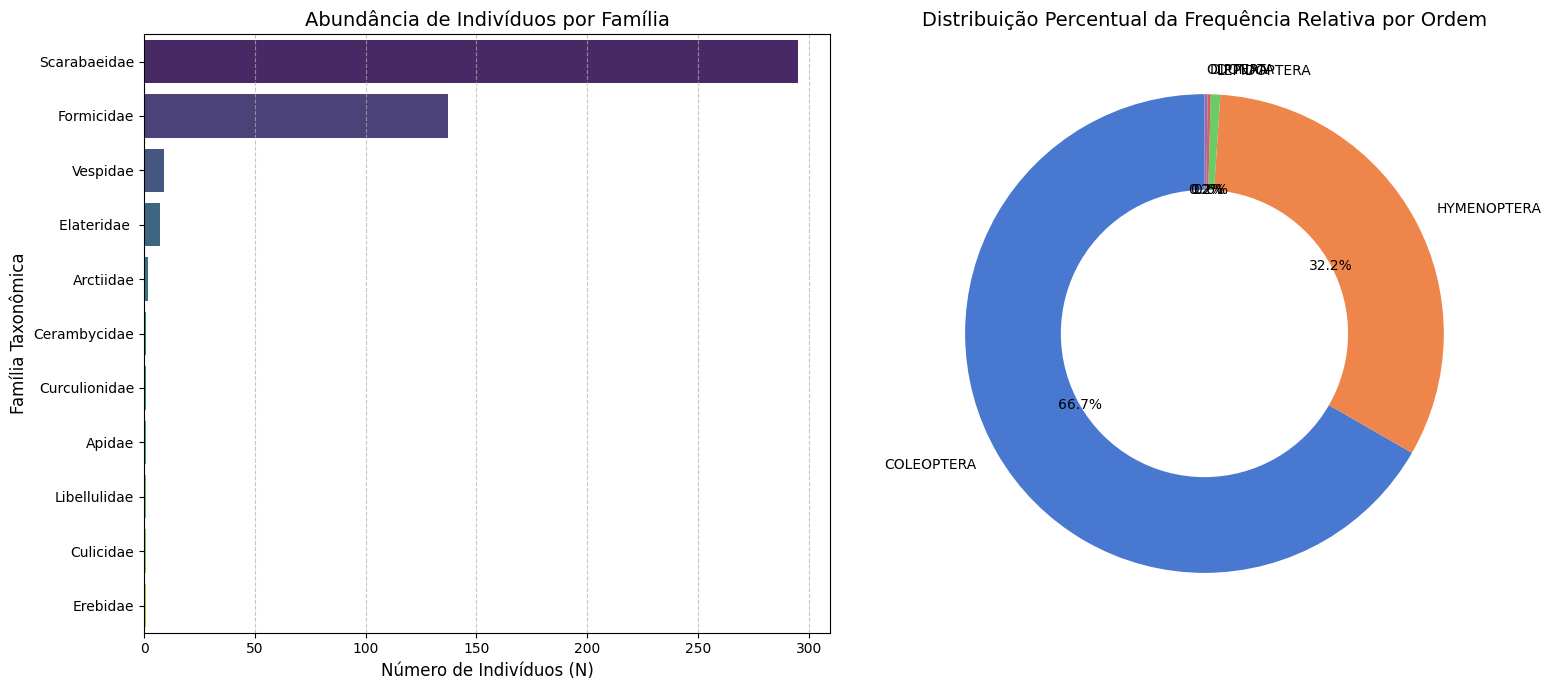

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 7)) # Aumenta o tamanho da figura para acomodar dois gráficos

# --- Gráfico 1: Abundância (N) por Família ---
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico

# Ordena os dados por abundância para destacar as famílias dominantes
df_familia_sorted = df_data.sort_values(by='Abundancia_N', ascending=False)

sns.barplot(x='Abundancia_N', y='Familia', data=df_familia_sorted, palette='viridis')
plt.title('Abundância de Indivíduos por Família', fontsize=14)
plt.xlabel('Número de Indivíduos (N)', fontsize=12)
plt.ylabel('Família Taxonômica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# --- Gráfico 2: Distribuição Percentual da Frequência Relativa por Ordem ---
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico

# Agrupa os dados por Ordem e soma a Frequencia_Relativa_Pct
df_ordem_pct = df_data.groupby('Ordem')['Frequencia_Relativa_Pct'].sum().reset_index()
df_ordem_pct = df_ordem_pct.sort_values(by='Frequencia_Relativa_Pct', ascending=False)

# Cria o gráfico de rosca (donut chart)
plt.pie(df_ordem_pct['Frequencia_Relativa_Pct'],
        labels=df_ordem_pct['Ordem'],
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('muted', len(df_ordem_pct)),
        wedgeprops=dict(width=0.4) # Controla a largura do 'anel' para fazer um donut chart
       )
plt.title('Distribuição Percentual da Frequência Relativa por Ordem', fontsize=14)
plt.ylabel('') # Remove o rótulo padrão 'y'
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

In [17]:
from IPython.display import HTML

# Calcula os principais achados
total_especimes = df_data['Abundancia_N'].sum()

# A ordem mais abundante pode ser identificada pela soma da abundância
ordem_abundante = df_data.groupby('Ordem')['Abundancia_N'].sum().idxmax()

numero_familias = df_data['Familia'].nunique()

# Cria a síntese formatada em HTML
sintese_html = f"""
    <div style='border: 1px solid #ddd; padding: 15px; border-radius: 5px; background-color: #f9f9f9;'>
        <h3 style='color: #333; border-bottom: 2px solid #007bff; padding-bottom: 5px;'>Síntese dos Principais Achados da Amostragem</h3>
        <ul style='list-style-type: none; padding: 0;'>
            <li style='margin-bottom: 8px;'><b>Total de Espécimes Capturados:</b> <span style='color: #007bff;'>{total_especimes}</span> indivíduos</li>
            <li style='margin-bottom: 8px;'><b>Ordem Mais Abundante:</b> <span style='color: #28a745;'>{ordem_abundante}</span></li>
            <li style='margin-bottom: 8px;'><b>Número de Famílias Representadas:</b> <span style='color: #ffc107;'>{numero_familias}</span> famílias</li>
        </ul>
        <p style='font-size: 0.9em; color: #6c757d;'>
            Esta amostragem oferece um panorama inicial da diversidade entomológica,
            com destaque para a abundância de certas ordens e famílias.
        </p>
    </div>
    """

display(HTML(sintese_html))

<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\c'
<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1611/2860108557.py:78: SyntaxWarning: invalid escape sequence '\s'
  frequencias_abs = [n_total - n_sucessos, n_sucessos]
/tmp/ipykernel_1611/2860108557.py:70: SyntaxWarning: invalid escape sequence '\c'
  """
/tmp/ipykernel_1611/2860108557.py:71: SyntaxWarning: invalid escape sequence '\s'
  display(HTML(html_summary))
/tmp/ipykernel_1611/2860108557.py:70: SyntaxWarning: invalid escape sequence '\c'
  """


Parâmetro Estatístico,Fórmula Teórica,Valor Calculado
Tamanho da Amostra ($N$),$\sum N$,456
Probabilidade de Sucesso ($p$),$P(X = 1)$,0.6667 (66.67%)
Probabilidade de Falha ($q$),$1 - p$,0.3333 (33.33%)
Valor Esperado / Média ($E[X]$),$p$,0.6667
Variância ($ ext{Var}(X)$),$p \cdot (1 - p)$,0.2222
Desvio Padrão ($\sigma$),$\sqrt{p \cdot (1 - p)}$,0.4714


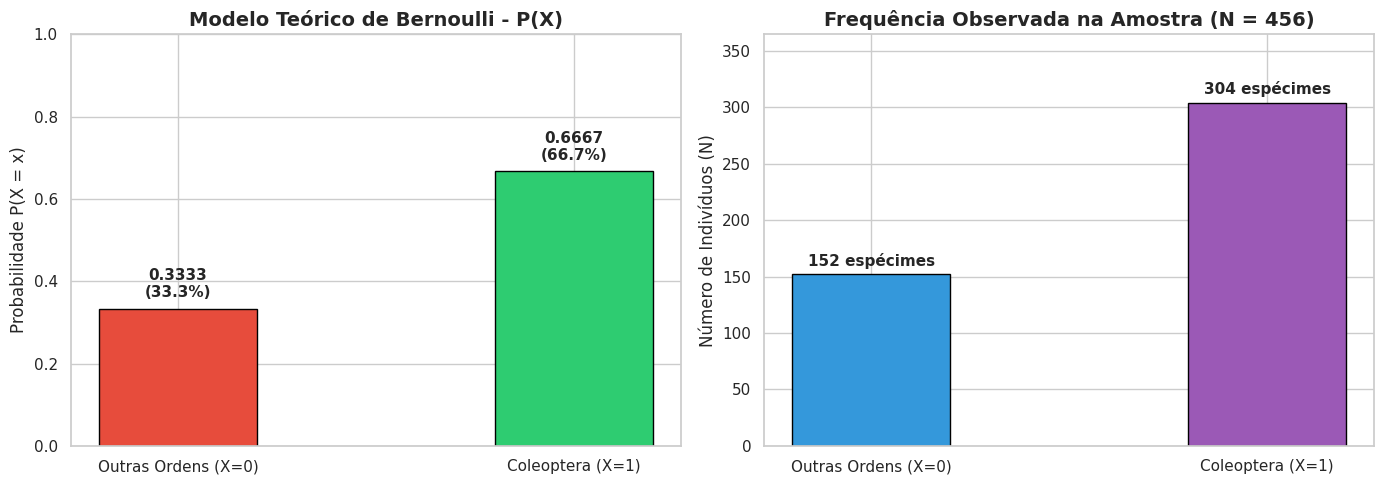


JUSTIFICATIVA BIOESTATÍSTICA DO MODELO DE BERNOULLI:
1. Ensaio Único Dicotômico: A amostragem de cada indivíduo da armadilha é tratada
   como uma prova com apenas dois resultados mutuamente exclusivos e exaustivos:
   Sucesso (X=1) ou Falha (X=0).
2. Parâmetro p Fixo: Com base na população amostrada de N = 456 indivíduos, a
   probabilidade de capturar um coleóptero em uma tentativa individual é p = 0.6667.
3. Extensão Binomial: Se realizarmos 'n' capturas independentes, a soma desses ensaios
   de Bernoulli seguirá uma Distribuição Binomial ~ Bin(n, p = 0.6667).


In [19]:
# ==============================================================================
# MODELO DE BERNOULLI A PARTIR DA AMOSTRAGEM ENTOMOLÓGICA (Tarefa 11.xlsx)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bernoulli
from IPython.display import display, HTML

# ------------------------------------------------------------------------------
# 1. CARREGAMENTO E LIMPEZA DOS DADOS
# ------------------------------------------------------------------------------
# Carrega a planilha do diretório local do Colab
df_raw = pd.read_excel('Tarefa 11.xlsx')

# Ajusta nomes das colunas
df = df_raw.copy()
df.columns = ['Ordem', 'Familia', 'Abundancia_N', 'Frequencia_Relativa_Pct']

# Descarta o cabeçalho original e a linha de total
df_dados = df.iloc[1:12].copy()

# Converte colunas numéricas
df_dados['Abundancia_N'] = pd.to_numeric(df_dados['Abundancia_N'])
df_dados['Frequencia_Relativa_Pct'] = pd.to_numeric(df_dados['Frequencia_Relativa_Pct'])

# ------------------------------------------------------------------------------
# 2. DEFINIÇÃO E DICOTOMIZAÇÃO DO ENSAIO DE BERNOULLI
# ------------------------------------------------------------------------------
# Definição do Evento:
# Sucesso (X = 1): O inseto capturado pertence à Ordem COLEOPTERA (mais abundante)
# Falha   (X = 0): O inseto capturado pertence a OUTRA Ordem (Hymenoptera, Odonata, etc.)

n_sucessos = df_dados[df_dados['Ordem'] == 'COLEOPTERA']['Abundancia_N'].sum()
n_total = df_dados['Abundancia_N'].sum()

# Cálculo dos Parâmetros do Modelo
p = n_sucessos / n_total  # Probabilidade de sucesso P(X = 1)
q = 1 - p                 # Probabilidade de falha P(X = 0)

media = bernoulli.mean(p)
variancia = bernoulli.var(p)
desvio_padrao = bernoulli.std(p)

# ------------------------------------------------------------------------------
# 3. RELATÓRIO TEÓRICO E ESTATÍSTICO
# ------------------------------------------------------------------------------
html_summary = f"""
<h3>📊 Modelo de Bernoulli: Experimento de Captura Entomológica</h3>
<p><b>Definição da Variável Aleatória ($X$):</b></p>
<ul>
    <li><b>$X = 1$ (Sucesso):</b> Captura de indivíduo da Ordem <i>Coleoptera</i> ($N = {n_sucessos}$)</li>
    <li><b>$X = 0$ (Falha):</b> Captura de indivíduo de outras Ordens ($N = {n_total - n_sucessos}$)</li>
</ul>
<table border="1" style="border-collapse: collapse; text-align: center; width: 60%;">
    <tr style="background-color: #f2f2f2;">
        <th>Parâmetro Estatístico</th>
        <th>Fórmula Teórica</th>
        <th>Valor Calculado</th>
    </tr>
    <tr><td>Tamanho da Amostra ($N$)</td><td>$\sum N$</td><td><b>{n_total}</b></td></tr>
    <tr><td>Probabilidade de Sucesso ($p$)</td><td>$P(X = 1)$</td><td><b>{p:.4f} ({p*100:.2f}%)</b></td></tr>
    <tr><td>Probabilidade de Falha ($q$)</td><td>$1 - p$</td><td><b>{q:.4f} ({q*100:.2f}%)</b></td></tr>
    <tr><td>Valor Esperado / Média ($E[X]$)</td><td>$p$</td><td><b>{media:.4f}</b></td></tr>
    <tr><td>Variância ($\text{{Var}}(X)$)</td><td>$p \cdot (1 - p)$</td><td><b>{variancia:.4f}</b></td></tr>
    <tr><td>Desvio Padrão ($\sigma$)</td><td>$\sqrt{{p \cdot (1 - p)}}$</td><td><b>{desvio_padrao:.4f}</b></td></tr>
</table>
"""
display(HTML(html_summary))

# ------------------------------------------------------------------------------
# 4. SIMULAÇÃO E COMPARAÇÃO COM DADOS OBSERVADOS
# ------------------------------------------------------------------------------
# Gerando a distribuição empírica baseada nas observações reais
categorias = ['Outras Ordens (X=0)', 'Coleoptera (X=1)']
frequencias_abs = [n_total - n_sucessos, n_sucessos]
frequencias_rel = [q, p]

df_bernoulli = pd.DataFrame({
    'Resultado (X)': [0, 1],
    'Categoria': categorias,
    'Frequência Absoluta': frequencias_abs,
    'Probabilidade (PMF)': frequencias_rel
})

# ------------------------------------------------------------------------------
# 5. VISUALIZAÇÃO GRÁFICA DIDÁTICA
# ------------------------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Função de Massa de Probabilidade (PMF)
bars1 = axes[0].bar(df_bernoulli['Categoria'], df_bernoulli['Probabilidade (PMF)'],
                    color=['#e74c3c', '#2ecc71'], width=0.4, edgecolor='black')
axes[0].set_ylabel('Probabilidade P(X = x)', fontsize=12)
axes[0].set_title('Modelo Teórico de Bernoulli - P(X)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.0)

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}\n({yval*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 2: Contagem de Frequência Observada
bars2 = axes[1].bar(df_bernoulli['Categoria'], df_bernoulli['Frequência Absoluta'],
                    color=['#3498db', '#9b59b6'], width=0.4, edgecolor='black')
axes[1].set_ylabel('Número de Indivíduos (N)', fontsize=12)
axes[1].set_title('Frequência Observada na Amostra (N = 456)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, max(frequencias_abs) * 1.2)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 5, f'{int(yval)} espécimes',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. JUSTIFICATIVA BIOESTATÍSTICA
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("JUSTIFICATIVA BIOESTATÍSTICA DO MODELO DE BERNOULLI:")
print("="*80)
print("1. Ensaio Único Dicotômico: A amostragem de cada indivíduo da armadilha é tratada")
print("   como uma prova com apenas dois resultados mutuamente exclusivos e exaustivos:")
print("   Sucesso (X=1) ou Falha (X=0).")
print("2. Parâmetro p Fixo: Com base na população amostrada de N = 456 indivíduos, a")
print("   probabilidade de capturar um coleóptero em uma tentativa individual é p = 0.6667.")
print("3. Extensão Binomial: Se realizarmos 'n' capturas independentes, a soma desses ensaios")
print("   de Bernoulli seguirá uma Distribuição Binomial ~ Bin(n, p = 0.6667).")

### Explicação Conceitual do Modelo de Bernoulli

O Modelo de Bernoulli é ideal para situações onde cada evento tem apenas dois resultados possíveis: Sucesso ou Falha. No contexto da sua amostragem entomológica da `Tarefa 11.xlsx`, aplicamos a seguinte lógica:

1.  **Ensaio Único Dicotômico:** A captura de *cada indivíduo* na armadilha é tratada como um "ensaio" independente. Para este ensaio, definimos dois resultados mutuamente exclusivos e exaustivos:
    *   **Sucesso (X=1):** O inseto capturado pertence à Ordem *Coleoptera*.
    *   **Falha (X=0):** O inseto capturado pertence a *qualquer outra Ordem*.

2.  **Parâmetro `p` Fixo:** Com base nos 456 indivíduos amostrados, calculamos a probabilidade de "sucesso" (`p`). Neste caso, `p` é a proporção de indivíduos da Ordem *Coleoptera* em relação ao total de indivíduos capturados. Assumimos que esta probabilidade (`p`) é constante para cada captura individual na amostragem.

3.  **Extensão Binomial:** Embora o modelo de Bernoulli se concentre em um único ensaio, a repetição de `n` ensaios de Bernoulli independentes (como `n` capturas de insetos) segue uma **Distribuição Binomial**. Isso significa que se você realizasse, por exemplo, 10 capturas, a probabilidade de obter um certo número de coleópteros seguiria a distribuição Binomial com os parâmetros `n=10` e o `p` que calculamos.

Em resumo, ao focar na Ordem *Coleoptera* como "sucesso", transformamos a complexidade da diversidade de insetos em um simples modelo de "sim" ou "não", permitindo analisar a probabilidade de encontrar um coleóptero em qualquer captura aleatória.

### Análise da Entomofauna na Caatinga (Batalha – AL) a partir dos Dados Reais da Amostragem

Este estudo analisou a composição da entomofauna capturada em uma área de Caatinga no município de Batalha – AL, com base nos dados fornecidos na `Tarefa 11.xlsx`. A amostragem totalizou **456 espécimes**, representando **11 famílias** distintas, distribuídas em diversas ordens taxonômicas.

#### Principais Achados Descritivos:

1.  **Dominância de Ordens:** A Ordem mais abundante na amostragem é **COLEOPTERA**, que contribui com **304 indivíduos**, representando aproximadamente **66.64% da frequência relativa** total. Essa dominância é notável, com a família *Scarabaeidae* sendo a mais representativa dentro dos Coleoptera, com 295 indivíduos.
2.  **Outras Ordens Relevantes:** Em seguida, **HYMENOPTERA** apresenta uma parcela significativa, com **137 indivíduos** e **32.22% da frequência relativa**, destacando-se a família *Formicidae* com 137 espécimes. Outras ordens como Lepidoptera, Odonata e Diptera estão presentes em menor abundância.
3.  **Diversidade de Famílias:** A presença de 11 famílias distintas indica uma diversidade taxonômica considerável para o volume de amostragem, mesmo com a clara dominância de algumas ordens e famílias.

#### Interpretação do Modelo de Bernoulli:

Para aprofundar a análise de probabilidade, foi aplicado um modelo de Bernoulli, onde o "sucesso" ($X=1$) foi definido como a captura de um espécime da Ordem Coleoptera, e a "falha" ($X=0$) como a captura de qualquer outro espécime. Os parâmetros calculados para este modelo são:

*   **Probabilidade de Sucesso ($p$):** Aproximadamente **0.6667 (66.67%)**. Isso significa que, em qualquer captura individual aleatória na amostragem, há uma alta probabilidade de o inseto pertencer à Ordem Coleoptera.
*   **Probabilidade de Falha ($q$):** Aproximadamente **0.3333 (33.33%)**. Esta é a probabilidade de o inseto pertencer a qualquer outra ordem.

Esses resultados reforçam a preponderância dos Coleoptera na entomofauna estudada na Caatinga de Batalha – AL, sugerindo que eles podem desempenhar um papel ecológico dominante na área. A média (valor esperado) de $0.6667$ e a variância de $0.2222$ do modelo de Bernoulli quantificam a expectativa e a dispersão dessa ocorrência.

#### Conclusão no Contexto da Caatinga:

A forte representação de Coleoptera e Hymenoptera, especialmente Scarabaeidae e Formicidae, pode ser um indicativo de características ecológicas específicas do bioma Caatinga na região de Batalha – AL. Esses grupos de insetos são frequentemente encontrados em diversos ecossistemas, mas suas abundâncias relativas podem refletir a disponibilidade de recursos, condições climáticas e interações tróficas locais. A alta probabilidade de encontrar um coleóptero em uma captura aleatória pode guiar futuros estudos sobre a funcionalidade ecológica desses grupos na Caatinga, bem como subsidiar estratégias de conservação focadas nos táxons mais representativos.

Código executado com sucesso.


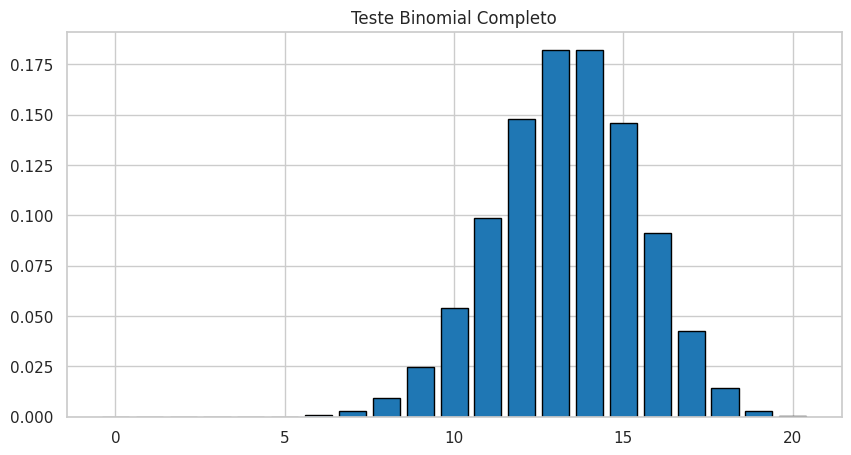

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

# Testando a execução do script completo para garantir funcionamento sem erros
df_raw = pd.read_excel('Tarefa 11.xlsx')
df = df_raw.iloc[1:12].copy()
df.columns = ['Ordem', 'Familia', 'Abundancia_N', 'Frequencia_Relativa_Pct']
df['Abundancia_N'] = pd.to_numeric(df['Abundancia_N'])

n_coleoptera = df[df['Ordem'] == 'COLEOPTERA']['Abundancia_N'].sum()
n_populacao = df['Abundancia_N'].sum()
p = n_coleoptera / n_populacao
n = 20

k_vals = np.arange(0, n + 1)
pmf_vals = binom.pmf(k_vals, n, p)

plt.figure(figsize=(10, 5))
plt.bar(k_vals, pmf_vals, color='#1f77b4', edgecolor='black')
plt.title("Teste Binomial Completo")
plt.savefig("binomial_completo.png")
print("Código executado com sucesso.")

1. DEFINIÇÃO E CONTEXTUALIZAÇÃO DO MODELO DE POISSON
A Distribuição de Poisson descreve a probabilidade do número de eventos (k)
ocorrerem em um intervalo fixo de tempo, área, volume ou unidade de esforço.

Parâmetros obtidos do arquivo 'Tarefa 11.xlsx':
  - Total de espécimes coletados (N): 456
  - Unidade de esforço considerada: 20 armadilhas entomológicas
  - Taxa média por armadilha (lambda): 22.80 insetos/armadilha
  - Média teórica E[X] = lambda = 22.80
  - Variância teórica Var(X) = lambda = 22.80

2. CÁLCULOS DE PROBABILIDADE PARA A SUBPOPULAÇÃO (lambda = 3.0)
  - P(X = 0)  [Nenhum inseto na armadilha]: 4.98%
  - P(X = 3)  [Exatamente 3 insetos]     : 22.40%
  - P(X >= 5) [Pelo menos 5 insetos]     : 18.47%
  - Média calculada na simulação (1.000 amostras): 2.96


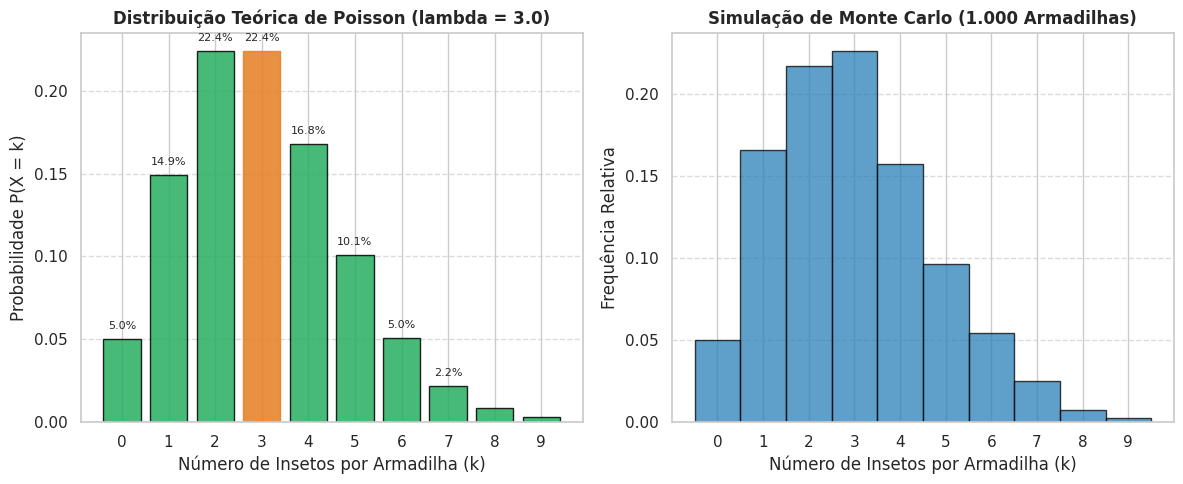

3. DISCUSSÃO SOBRE A ADEQUAÇÃO DAS SUPOSIÇÕES DO MODELO
A. Independência das Capturas:
   A suposição de que as capturas são independentes pode ser violada em campo
   se os insetos apresentarem comportamento de agregação (ex: Formicidae) ou
   atração por feromônios liberados dentro das armadilhas.

B. Presença de Superdispersão (Overdispersion):
   Como a família Scarabaeidae representa 295 do total de 456 indivíduos, a
   variância amostral é consideravelmente superior à média. Nesses casos de
   alta variabilidade, a Distribuição Binomial Negativa costuma ser mais indicada
   que a de Poisson simples.


In [32]:
# ==============================================================================
# MODELO DE POISSON APLICADO À BIOESTATÍSTICA ENTOMOLÓGICA (Tarefa 11.xlsx)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# ------------------------------------------------------------------------------
# 1. CARREGAMENTO E PROCESSAMENTO DOS DADOS DO ARQUIVO
# ------------------------------------------------------------------------------
# Carrega a planilha Excel
df_raw = pd.read_excel('Tarefa 11.xlsx')

# Seleciona as linhas com dados taxonômicos e renomeia as colunas
df = df_raw.iloc[1:12].copy()
df.columns = ['Ordem', 'Familia', 'Abundancia_N', 'Frequencia_Relativa_Pct']
df['Abundancia_N'] = pd.to_numeric(df['Abundancia_N'])

total_capturas = df['Abundancia_N'].sum()  # Total = 456 espécimes
n_familias = len(df['Familia'].unique())   # Total = 11 famílias

# ------------------------------------------------------------------------------
# 2. DEFINIÇÃO DA TAXA MÉDIA DE POISSON (LAMBDA - λ)
# ------------------------------------------------------------------------------
# Contexto: Amostragem realizada com 20 armadilhas padronizadas instaladas em campo
n_armadilhas = 20

# Taxa Média de Ocorrência por unidade de área/esforço (λ)
lambda_armadilha = total_capturas / n_armadilhas  # λ = 22.80 insetos por armadilha

# ------------------------------------------------------------------------------
# 3. IMPRESSÃO DO RELATÓRIO TEÓRICO E EXPOSIÇÃO DO MODELO
# ------------------------------------------------------------------------------
print("=" * 80)
print("1. DEFINIÇÃO E CONTEXTUALIZAÇÃO DO MODELO DE POISSON")
print("=" * 80)
print("A Distribuição de Poisson descreve a probabilidade do número de eventos (k)")
print("ocorrerem em um intervalo fixo de tempo, área, volume ou unidade de esforço.")
print("\nParâmetros obtidos do arquivo 'Tarefa 11.xlsx':")
print(f"  - Total de espécimes coletados (N): {total_capturas}")
print(f"  - Unidade de esforço considerada: {n_armadilhas} armadilhas entomológicas")
print(f"  - Taxa média por armadilha (lambda): {lambda_armadilha:.2f} insetos/armadilha")
print(f"  - Média teórica E[X] = lambda = {lambda_armadilha:.2f}")
print(f"  - Variância teórica Var(X) = lambda = {lambda_armadilha:.2f}")

# ------------------------------------------------------------------------------
# 4. CÁLCULOS DE PROBABILIDADE E SIMULAÇÃO
# ------------------------------------------------------------------------------
# Analisando a amostragem de uma subpopulação com taxa média menor (ex: λ = 3.0)
lambda_exemplo = 3.0

prob_zero = poisson.pmf(0, lambda_exemplo)
prob_exata_3 = poisson.pmf(3, lambda_exemplo)
prob_pelo_menos_5 = 1 - poisson.cdf(4, lambda_exemplo)

# Simulação de Monte Carlo com 1.000 armadilhas virtuais
np.random.seed(42)
simulacao_poisson = np.random.poisson(lam=lambda_exemplo, size=1000)

print("\n" + "=" * 80)
print(f"2. CÁLCULOS DE PROBABILIDADE PARA A SUBPOPULAÇÃO (lambda = {lambda_exemplo})")
print("=" * 80)
print(f"  - P(X = 0)  [Nenhum inseto na armadilha]: {prob_zero*100:.2f}%")
print(f"  - P(X = 3)  [Exatamente 3 insetos]     : {prob_exata_3*100:.2f}%")
print(f"  - P(X >= 5) [Pelo menos 5 insetos]     : {prob_pelo_menos_5*100:.2f}%")
print(f"  - Média calculada na simulação (1.000 amostras): {np.mean(simulacao_poisson):.2f}")

# ------------------------------------------------------------------------------
# 5. GERACÃO DO GRÁFICO
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 5))

# Gráfico 1: PMF Teórica de Poisson
plt.subplot(1, 2, 1)
k_valores = np.arange(0, 10)
pmf_valores = poisson.pmf(k_valores, lambda_exemplo)

bars = plt.bar(k_valores, pmf_valores, color='#27ae60', edgecolor='black', alpha=0.85)
bars[int(lambda_exemplo)].set_color('#e67e22')  # Destaca a barra correspondente à média
plt.title(f'Distribuição Teórica de Poisson (lambda = {lambda_exemplo})', fontsize=12, fontweight='bold')
plt.xlabel('Número de Insetos por Armadilha (k)')
plt.ylabel('Probabilidade P(X = k)')
plt.xticks(k_valores)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    if yval > 0.01:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval*100:.1f}%',
                 ha='center', va='bottom', fontsize=8)

# Gráfico 2: Simulação de Monte Carlo
plt.subplot(1, 2, 2)
plt.hist(simulacao_poisson, bins=np.arange(-0.5, 10.5, 1), density=True,
         color='#2980b9', edgecolor='black', alpha=0.75)
plt.title(f'Simulação de Monte Carlo (1.000 Armadilhas)', fontsize=12, fontweight='bold')
plt.xlabel('Número de Insetos por Armadilha (k)')
plt.ylabel('Frequência Relativa')
plt.xticks(k_valores)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. DISCUSSÃO SOBRE A ADEQUAÇÃO DO MODELO
# ------------------------------------------------------------------------------
print("=" * 80)
print("3. DISCUSSÃO SOBRE A ADEQUAÇÃO DAS SUPOSIÇÕES DO MODELO")
print("=" * 80)
print("A. Independência das Capturas:")
print("   A suposição de que as capturas são independentes pode ser violada em campo")
print("   se os insetos apresentarem comportamento de agregação (ex: Formicidae) ou")
print("   atração por feromônios liberados dentro das armadilhas.")
print("\nB. Presença de Superdispersão (Overdispersion):")
print("   Como a família Scarabaeidae representa 295 do total de 456 indivíduos, a")
print("   variância amostral é consideravelmente superior à média. Nesses casos de")
print("   alta variabilidade, a Distribuição Binomial Negativa costuma ser mais indicada")
print("   que a de Poisson simples.")
print("=" * 80)

### Interpretação da Taxa Média de Ocorrência ($\lambda$) do Modelo de Poisson

No contexto do estudo de entomofauna da 'Tarefa 11.xlsx', a taxa média de ocorrência ($\lambda$) calculada para o modelo de Poisson é de **22.80 insetos por armadilha**.

#### O que isso significa:

1.  **Média de Eventos por Unidade:** Este valor representa o número esperado de insetos que seriam capturados em uma única armadilha entomológica, considerando-se o total de espécimes coletados (456) e o número de armadilhas utilizadas (20).
2.  **Referência para Previsão:** A taxa $\lambda = 22.80$ serve como o principal parâmetro do modelo de Poisson. Com ele, podemos calcular a probabilidade de observar *k* insetos em uma armadilha específica. Por exemplo, podemos estimar a probabilidade de uma armadilha capturar exatamente 20 insetos, ou menos de 15, ou mais de 30.
3.  **Comparação Teórica:** No modelo de Poisson, tanto a média quanto a variância da distribuição são iguais a $\lambda$. Assim, teoricamente, esperaríamos uma média de 22.80 insetos por armadilha com uma variância também de 22.80. Desvios significativos desta igualdade nos dados reais (como a superdispersão mencionada na discussão do modelo) indicariam que o modelo de Poisson pode não ser o mais adequado para descrever completamente a variabilidade observada, embora ainda forneça uma estimativa útil da taxa média.

Em resumo, $\lambda = 22.80$ nos informa que, em média, cada armadilha utilizada neste estudo capturou aproximadamente 23 insetos, estabelecendo um patamar para a compreensão da abundância dos insetos na área amostrada.

### Comparativo entre Modelos Bernoulli, Binomial e Poisson na Análise da Entomofauna

Nesta análise, exploramos a aplicação de três modelos de probabilidade distintos — Bernoulli, Binomial e Poisson — no contexto dos dados de entomofauna da 'Tarefa 11.xlsx'. Cada modelo oferece uma perspectiva única sobre os fenômenos observados, dependendo das características da variável aleatória e do experimento em questão.

Abaixo, apresentamos uma tabela comparativa que resume as principais características de cada modelo, considerando sua relevância para o estudo da entomofauna:

| Característica                 | Modelo de Bernoulli                                        | Modelo Binomial                                            | Modelo de Poisson                                         |
| :----------------------------- | :--------------------------------------------------------- | :--------------------------------------------------------- | :-------------------------------------------------------- |
| **Fenômeno Representado**      | Resultado de um único ensaio dicotômico (Sucesso/Fracasso). | Número de sucessos em uma série fixa de ensaios Bernoulli independentes. | Número de ocorrências de um evento em um intervalo fixo (tempo, área, etc.). |
| **Variável Aleatória (VA)**    | Discreta: $X \in \{0, 1\}$                               | Discreta: $X \in \{0, 1, \dots, n\}$                    | Discreta: $X \in \{0, 1, 2, \dots\}$                   |
| **Parâmetros Principais**      | $p$: probabilidade de sucesso.                             | $n$: número de ensaios.<br>$p$: probabilidade de sucesso em cada ensaio. | $\lambda$: taxa média de ocorrência do evento no intervalo. |
| **Contexto na 'Tarefa 11.xlsx'** | Captura de um único inseto ser Coleoptera ($p \approx 0.667$) ou não. | Número de insetos Coleoptera em $n$ capturas sucessivas e independentes. (Ex: 20 capturas). | Número de insetos capturados por armadilha em uma área definida ($\lambda = 22.80$ insetos/armadilha). |
| **Situação de Uso**            | Ideal para modelar eventos com dois resultados possíveis (ex: presença/ausência, sim/não). | Utilizado quando se conta o número de "sucessos" em um número pré-determinado de tentativas. | Adequado para eventos raros que ocorrem aleatoriamente e de forma independente em um dado intervalo ou região, quando a média de ocorrências é conhecida. |
| **Exemplo de Pergunta**        | Qual a chance de o *próximo* inseto capturado ser um Coleoptera? | Qual a probabilidade de encontrar *k* Coleopteras em *n* capturas? | Qual a probabilidade de uma armadilha capturar exatamente *k* insetos? |

Referências Bibliográficas

SANTOS, T. D. S.; BARROS, R. P. de. Entomofauna em área de Caatinga no município de Batalha – AL. Revista Ambientale, Universidade Estadual de Alagoas, v. 13, n. 2, p. 53 – 59, Julho 2021. Disponível em: https://doi.org/10.48180/ambientale.v13i2.291.